# EDA from clean component tables

Notebook n?y ch? load c?c b?ng th?nh ph?n xu?t ra t? `clean.ipynb`, sau ?? aggregate t?m v? visualize tr?c ti?p trong notebook.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 120)

CLEAN_DIR = Path('cleaned_data')
required_tables = ['customer_clean', 'deposit_clean', 'lending_clean', 'card_clean', 'transaction_clean', 'activity_clean']
missing = [name for name in required_tables if not (CLEAN_DIR / f'{name}.parquet').exists()]
if missing:
    raise FileNotFoundError(f'Missing clean tables: {missing}. Run clean.ipynb first.')


## 1. Load clean component tables

In [2]:
customer_clean = pd.read_parquet(CLEAN_DIR / 'customer_clean.parquet')
deposit_clean = pd.read_parquet(CLEAN_DIR / 'deposit_clean.parquet')
lending_clean = pd.read_parquet(CLEAN_DIR / 'lending_clean.parquet')
card_clean = pd.read_parquet(CLEAN_DIR / 'card_clean.parquet')
transaction_clean = pd.read_parquet(CLEAN_DIR / 'transaction_clean.parquet')
activity_clean = pd.read_parquet(CLEAN_DIR / 'activity_clean.parquet')

for df in [deposit_clean, lending_clean, card_clean, transaction_clean, activity_clean]:
    df['MONTH'] = pd.to_datetime(df['MONTH'], errors='coerce').dt.to_period('M').dt.to_timestamp('M')
for col in ['CLIENT_CREATE_DATE', 'DATE_OF_BIRTH', 'IB_REGISTER_DATE']:
    customer_clean[col] = pd.to_datetime(customer_clean[col], errors='coerce')
transaction_clean['TRANS_DATE'] = pd.to_datetime(transaction_clean['TRANS_DATE'], errors='coerce')
activity_clean['ACTIVITY_DATE'] = pd.to_datetime(activity_clean['ACTIVITY_DATE'], errors='coerce')

qa = pd.DataFrame([
    {'table': name, 'rows': len(df), 'cols': df.shape[1], 'customers': df['CUSTOMER_NUMBER'].nunique()}
    for name, df in {
        'customer_clean': customer_clean,
        'deposit_clean': deposit_clean,
        'lending_clean': lending_clean,
        'card_clean': card_clean,
        'transaction_clean': transaction_clean,
        'activity_clean': activity_clean,
    }.items()
])
qa


,table,rows,cols,customers
0,customer_clean,285929,13,285929
1,deposit_clean,1258424,6,223817
2,lending_clean,576431,7,102014
3,card_clean,871589,7,150459
4,transaction_clean,1417982,15,52485
5,activity_clean,16132674,7,77740


## 2. Aggregate to customer-level EDA base

B?ng `customer_eda_base` ch? l? b?ng t?m trong notebook: n?n l? `customer_clean` 1 d?ng/KH, c?c b?ng product l?y latest snapshot, transaction/activity aggregate l?n c?p KH.

In [3]:
def age_bucket(age):
    bins = [15, 25, 35, 45, 55, 65, 81]
    labels = ['15 - 25', '25 - 35', '35 - 45', '45 - 55', '55 - 65', '65 - 80']
    return pd.cut(age, bins=bins, labels=labels, right=False)


def latest_by_customer(df, cols):
    if df.empty:
        return pd.DataFrame(columns=['CUSTOMER_NUMBER', *cols])
    work = df.sort_values(['CUSTOMER_NUMBER', 'MONTH'])
    return work.groupby('CUSTOMER_NUMBER', as_index=False).tail(1)[['CUSTOMER_NUMBER', *cols]]


base = customer_clean.copy()
base['is_ib'] = base['IB_REGISTER_DATE'].notna()
base['AGE_AT_2019'] = ((pd.Timestamp('2019-12-31') - base['DATE_OF_BIRTH']).dt.days / 365.25)
base['age_bucket'] = age_bucket(base['AGE_AT_2019'])

product_tables = [
    latest_by_customer(deposit_clean, ['COUNT_CA_ACCT', 'AVG_CA_BALANCE', 'COUNT_TD_ACCT', 'AVG_TD_BALANCE']),
    latest_by_customer(lending_clean, ['COUNT_OF_LOAN', 'AVG_LOAN_AMOUNT', 'OVERDUE_LENDING']),
    latest_by_customer(card_clean, ['COUNT_CREDITCARD', 'COUNT_DEBITCARD', 'OVERDUE_CREDIT', 'LIMIT_AMT_CREDIT', 'OUTSTANDING_BAL_CREDIT']),
]
for add in product_tables:
    base = base.merge(add, on='CUSTOMER_NUMBER', how='left')

base[['COUNT_CREDITCARD', 'COUNT_DEBITCARD']] = base[['COUNT_CREDITCARD', 'COUNT_DEBITCARD']].fillna(0)
base['COUNT_CARD'] = base[['COUNT_CREDITCARD', 'COUNT_DEBITCARD']].max(axis=1)
product_cols = ['COUNT_CA_ACCT', 'COUNT_TD_ACCT', 'COUNT_OF_LOAN', 'COUNT_CARD']
base[product_cols] = base[product_cols].fillna(0)
base['product_depth'] = base[product_cols].gt(0).sum(axis=1)

deposit_customer = deposit_clean.groupby('CUSTOMER_NUMBER').agg(
    bank_engagement_months=('MONTH', 'nunique'),
)
transaction_customer = transaction_clean.groupby('CUSTOMER_NUMBER').agg(
    trans_records=('TRANS_NO', 'size'),
    trans_no=('TRANS_NO', 'sum'),
    trans_amount=('TRANS_AMOUNT', 'sum'),
    trans_months=('MONTH', 'nunique'),
    internal_transfer_rows=('IS_INTERNAL_TRANSFER', 'sum'),
)
activity_customer = activity_clean.groupby('CUSTOMER_NUMBER').agg(
    activity_records=('ACTIVITY_NO', 'size'),
    activity_no=('ACTIVITY_NO', 'sum'),
    activity_months=('MONTH', 'nunique'),
    login=('ACTIVITY_NAME', lambda s: (s == 'LOGIN').sum()),
)
base = base.join(deposit_customer, on='CUSTOMER_NUMBER').join(transaction_customer, on='CUSTOMER_NUMBER').join(activity_customer, on='CUSTOMER_NUMBER')
for col in ['bank_engagement_months', 'trans_records', 'trans_no', 'trans_amount', 'trans_months', 'internal_transfer_rows', 'activity_records', 'activity_no', 'activity_months', 'login']:
    base[col] = base[col].fillna(0)
base['has_txn'] = base['trans_records'].gt(0)
base['has_activity'] = base['activity_records'].gt(0)
base['digital_engaged_months'] = base[['activity_months', 'trans_months']].max(axis=1)
base['engaged_months'] = base['bank_engagement_months']

customer_eda_base = base
customer_eda_base.head()


,CUSTOMER_NUMBER,CLIENT_SEX,CLIENT_CREATE_DATE,DATE_OF_BIRTH,STAFF,IB_REGISTER_DATE,EB_REGISTER_CHANNEL,SMS,VERIFY_METHOD,AGE,Occupation_Group,Education_Level,Marital_Status,is_ib,AGE_AT_2019,age_bucket,COUNT_CA_ACCT,AVG_CA_BALANCE,COUNT_TD_ACCT,AVG_TD_BALANCE,COUNT_OF_LOAN,AVG_LOAN_AMOUNT,OVERDUE_LENDING,COUNT_CREDITCARD,COUNT_DEBITCARD,OVERDUE_CREDIT,LIMIT_AMT_CREDIT,OUTSTANDING_BAL_CREDIT,COUNT_CARD,product_depth,bank_engagement_months,trans_records,trans_no,trans_amount,trans_months,internal_transfer_rows,activity_records,activity_no,activity_months,login,has_txn,has_activity,digital_engaged_months,engaged_months
0,639362,M,2019-04-23,1996-01-01,N,2019-04-23,BRANCH,Y,SMS,30.0,Working,higher education,Married,True,23.997262,15 - 25,1.0,66545.16,0.0,0.0,0.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0,1.0,2,9.0,13.0,13.0,21231000.0,4.0,8.0,67.0,92.0,6.0,20.0,True,True,6.0,9.0
1,452440,M,2019-01-11,1999-10-10,N,2019-01-11,BRANCH,Y,SMART_OTP,27.0,Working,higher education,Single / not married,True,20.224504,15 - 25,1.0,78645.16,0.0,0.0,0.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0,1.0,2,12.0,0.0,0.0,0.0,0.0,0.0,54.0,327.0,2.0,13.0,False,True,2.0,12.0
2,326290,F,2019-05-27,1996-06-29,N,2019-05-27,BRANCH,Y,SMS,30.0,Working,higher education,Married,True,23.504449,15 - 25,1.0,3102913.48,0.0,0.0,0.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0,1.0,2,8.0,47.0,50.0,86799392.0,7.0,42.0,353.0,612.0,7.0,98.0,True,True,7.0,8.0
3,20802,M,2019-11-12,1992-08-07,N,2019-11-12,BRANCH,Y,SMART_OTP,34.0,Working,higher education,Married,True,27.397673,25 - 35,0.0,NaN,0.0,NaN,0.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0,1.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,0.0,0.0
4,114244,M,2019-03-29,1973-10-15,N,2019-03-29,BRANCH,N,SMS,53.0,Commercial associate,secondary/ secondary special,Single / not married,True,46.209446,45 - 55,1.0,226368.00,0.0,0.0,1.0,290625000.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,2,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,0.0,10.0


## 3. KPI summary

In [4]:
ca_total = customer_eda_base['AVG_CA_BALANCE'].fillna(0).sum()
td_total = customer_eda_base['AVG_TD_BALANCE'].fillna(0).sum()
casa_proxy = ca_total / (ca_total + td_total)
age_at_2019 = ((pd.Timestamp('2019-12-31') - customer_eda_base['DATE_OF_BIRTH']).dt.days / 365.25)
ib_base = customer_eda_base[customer_eda_base['is_ib']].copy()
non_base = customer_eda_base[~customer_eda_base['is_ib']].copy()
ib_no_txn_base = ib_base[~ib_base['has_txn']].copy()

outside_bank = transaction_clean['TRANS_LV2'].eq('Outside_bank')
topup = transaction_clean['TRANS_LV1'].eq('Topup')
outside_amount = transaction_clean.loc[outside_bank, 'TRANS_AMOUNT'].sum()
topup_amount = transaction_clean.loc[topup, 'TRANS_AMOUNT'].sum()
txn_customers = customer_eda_base['has_txn'].sum()

channel_txn_rate = ib_base.groupby('EB_REGISTER_CHANNEL')['has_txn'].mean() * 100
channel_count = ib_base['EB_REGISTER_CHANNEL'].value_counts()
ib_reg_month = ib_base.assign(reg_month=ib_base['IB_REGISTER_DATE'].dt.month)
ib_depth_txn_rate = ib_base.groupby('product_depth')['has_txn'].mean() * 100
ib_depth_loyalty = ib_base.groupby('product_depth')['digital_engaged_months'].mean()

nonib_master_path = Path('Cluster_nonIB') / 'output' / 'nonib_master.parquet'
if nonib_master_path.exists():
    nonib_master_kpi = pd.read_parquet(nonib_master_path)
    ready_flags_kpi = pd.DataFrame({
        'card': nonib_master_kpi[['CREDITCARD_MAX', 'DEBITCARD_MAX']].gt(0).any(axis=1),
        'td': nonib_master_kpi['TD_ACCT_MAX'].gt(0),
        'loan': nonib_master_kpi['LOAN_COUNT_MAX'].gt(0),
        'young_2sp': nonib_master_kpi['AGE'].between(22, 41, inclusive='both') & nonib_master_kpi['PRODUCT_COUNT'].ge(2),
        'engaged_6m': nonib_master_kpi['MONTHS_WITH_DEPOSIT'].ge(6),
        'balance_10m': nonib_master_kpi['CA_BALANCE_LAST'].gt(10_000_000),
    })
    nonib_ready_score = ready_flags_kpi.sum(axis=1).clip(upper=5)
    nonib_median_td_million = nonib_master_kpi.loc[nonib_master_kpi['TD_BALANCE_LAST'].fillna(0).gt(0), 'TD_BALANCE_LAST'].median() / 1_000_000
else:
    nonib_ready_score = pd.Series(dtype='int64')
    nonib_median_td_million = np.nan

kpi = pd.DataFrame([
    ['Tổng khách hàng', f'{len(customer_eda_base):,.0f}'.replace(',', '.')],
    ['Đã đăng ký IB', f"{customer_eda_base['is_ib'].mean() * 100:.1f}% ({int(customer_eda_base['is_ib'].sum()):,.0f} KH)".replace(',', '.')],
    ['Non-IB', f"{(~customer_eda_base['is_ib']).mean() * 100:.1f}% ({int((~customer_eda_base['is_ib']).sum()):,.0f} KH)".replace(',', '.')],
    ['Tuổi trung bình / median', f"{age_at_2019.mean():.1f} / {age_at_2019.median():.0f}"],
    ['Tổng giao dịch 2019', f"{len(transaction_clean) / 1_000_000:.2f}M"],
    ['Chuyển ngoài hệ thống', f"{outside_bank.mean() * 100:.1f}% ({outside_bank.sum():,.0f} GD)".replace(',', '.')],
    ['Outflow / Inflow', f"{outside_amount / topup_amount:.0f}x ({outside_amount / 1_000_000_000:.0f} tỷ vs {topup_amount / 1_000_000_000:.1f} tỷ)".replace(',', '.')],
    ['KH có giao dịch', f"{int(txn_customers):,.0f} ({txn_customers / len(customer_eda_base) * 100:.1f}%)".replace(',', '.')],
    ['CASA ratio', f'{casa_proxy * 100:.1f}%'],
    ['Median CA balance', f"{customer_eda_base.loc[customer_eda_base['AVG_CA_BALANCE'].fillna(0).gt(0), 'AVG_CA_BALANCE'].median() / 1_000:.0f}K"],
    ['Median CA balance Non-IB', f"{non_base.loc[non_base['AVG_CA_BALANCE'].fillna(0).gt(0), 'AVG_CA_BALANCE'].median() / 1_000:.0f}K"],
    ['KH không có tiền gửi', f"{(customer_eda_base[['AVG_CA_BALANCE', 'AVG_TD_BALANCE']].fillna(0).sum(axis=1).eq(0)).mean() * 100:.1f}%"],
    ['Chỉ có 0-1 sản phẩm', f"{customer_eda_base['product_depth'].le(1).mean() * 100:.1f}%"],
    ['Có ít nhất 1 sản phẩm', f"{customer_eda_base['product_depth'].ge(1).mean() * 100:.1f}% ({customer_eda_base['product_depth'].ge(1).sum():,.0f} KH)".replace(',', '.')],
    ['Avg sản phẩm/KH', f"{customer_eda_base['product_depth'].mean():.2f}"],
    ['Không có SP nào', f"{customer_eda_base['product_depth'].eq(0).mean() * 100:.1f}% ({customer_eda_base['product_depth'].eq(0).sum():,.0f} KH)".replace(',', '.')],
    ['IB không GD: có >=1 SP', f"{ib_no_txn_base['product_depth'].ge(1).mean() * 100:.1f}% ({ib_no_txn_base['product_depth'].ge(1).sum():,.0f} KH)".replace(',', '.')],
    ['IB không GD: avg SP/KH', f"{ib_no_txn_base['product_depth'].mean():.2f} vs {ib_base[ib_base['has_txn']]['product_depth'].mean():.2f}"],
    ['IB không GD: không có SP', f"{ib_no_txn_base['product_depth'].eq(0).mean() * 100:.2f}% ({ib_no_txn_base['product_depth'].eq(0).sum():,.0f} KH)".replace(',', '.')],
    ['Txn rate AUTO-JOB', f"{channel_txn_rate.get('AUTO-JOB', np.nan):.1f}% ({channel_count.get('AUTO-JOB', 0):,.0f} KH)".replace(',', '.')],
    ['Txn rate BRANCH', f"{channel_txn_rate.get('BRANCH', np.nan):.1f}%"],
    ['Txn rate KH đăng ký tháng 12', f"{ib_reg_month.loc[ib_reg_month['reg_month'].eq(12), 'has_txn'].mean() * 100:.1f}%"],
    ['IB: KH kẹt ở 2 sản phẩm', f"{ib_base['product_depth'].eq(2).mean() * 100:.1f}%"],
    ['IB: txn rate khi có 4 SP', f"{ib_depth_txn_rate.get(4, np.nan):.1f}%"],
    ['IB: loyalty khi có 4 SP', f"{ib_depth_loyalty.get(4, np.nan):.1f}T"],
    ['Non-IB: score 0', f"{nonib_ready_score.eq(0).mean() * 100:.1f}% ({nonib_ready_score.eq(0).sum():,.0f} KH)".replace(',', '.')],
    ['Non-IB: có >=1 tín hiệu ready', f"{nonib_ready_score.ge(1).mean() * 100:.1f}% ({nonib_ready_score.ge(1).sum():,.0f} KH)".replace(',', '.')],
    ['Non-IB: median TD balance', f"{nonib_median_td_million:.0f}M"],
], columns=['metric', 'value'])
kpi


,metric,value
0,Tổng khách hàng,285.929
1,Đã đăng ký IB,55.6% (158.929 KH)
2,Non-IB,44.4% (127.000 KH)
3,Tuổi trung bình / median,35.1 / 33
4,Tổng giao dịch 2019,1.42M
5,Chuyển ngoài hệ thống,53.6% (759.796 GD)
6,Outflow / Inflow,130x (9324 tỷ vs 71.8 tỷ)
7,KH có giao dịch,52.480 (18.4%)
8,CASA ratio,6.5%
9,Median CA balance,355K


## 4. Visualizations

In [5]:
BLUE = '#0b3f8a'
LIGHT_BLUE = '#8fc0ff'
GREEN = '#20a174'
ORANGE = '#ff7a22'
YELLOW = '#f7bd5b'
RED = '#e34f4f'
DARK = '#17202a'
GRID = '#e6e6e6'


def style_axes(ax, title=None):
    if title:
        ax.set_title(title, loc='left', fontsize=11, fontweight='bold', color=DARK)
    ax.grid(axis='y', color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')


ib = customer_eda_base[customer_eda_base['is_ib']].copy()
non = customer_eda_base[~customer_eda_base['is_ib']].copy()



## T?ng th?

C?c ch? s? v? ph?n b? chung c?a to?n b? t?p kh?ch h?ng.

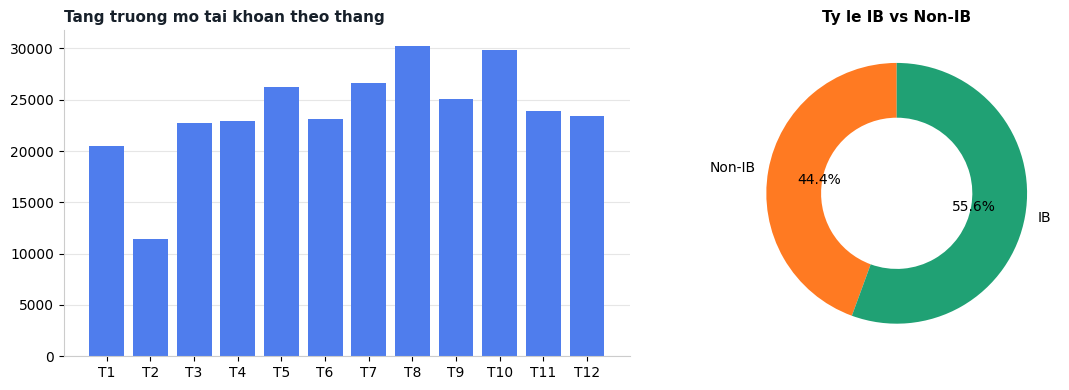

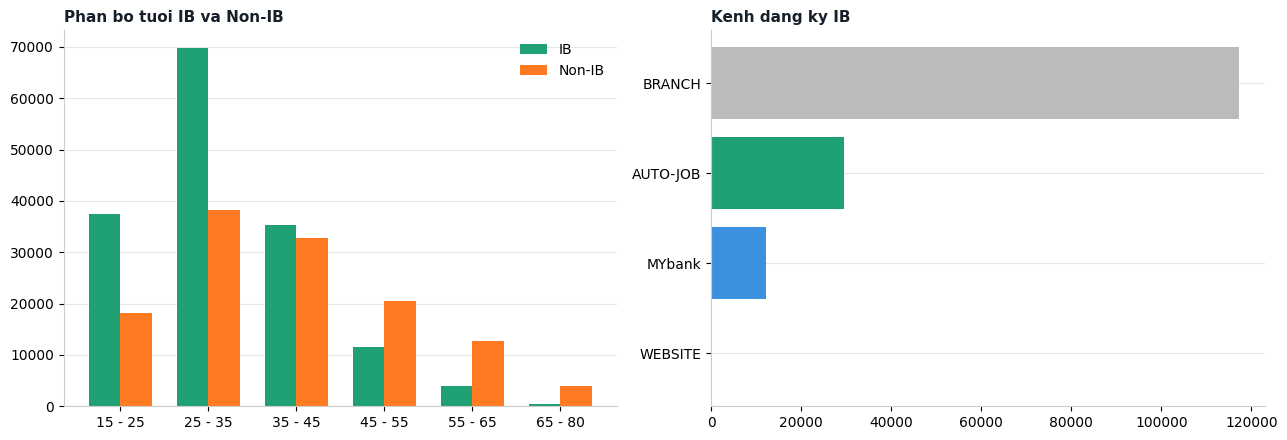

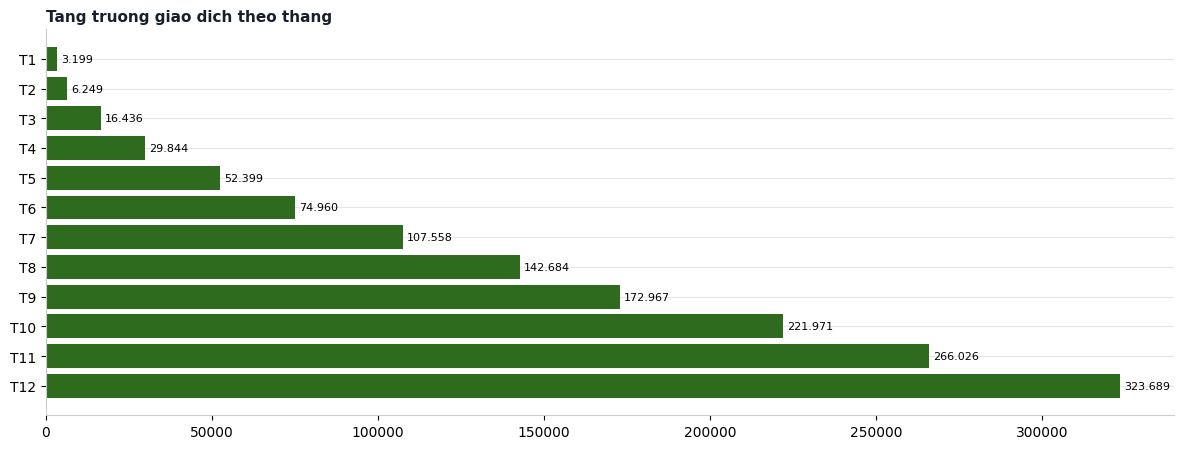

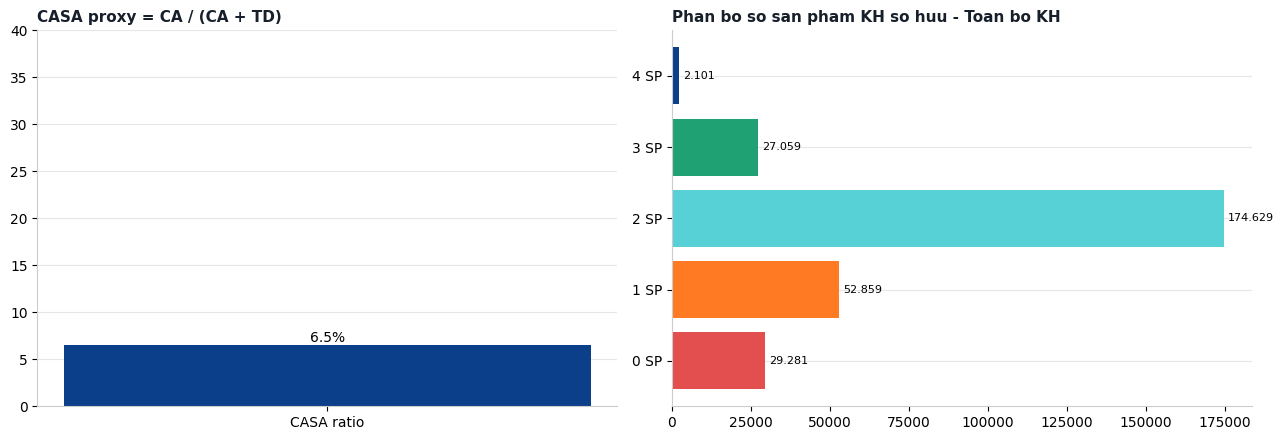

In [6]:
# 01 overview
open_month = (
    customer_eda_base.dropna(subset=['CLIENT_CREATE_DATE'])
    .assign(open_month=lambda x: x['CLIENT_CREATE_DATE'].dt.month)
    .groupby('open_month')['CUSTOMER_NUMBER']
    .nunique()
    .reindex(range(1, 13), fill_value=0)
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar([f'T{i}' for i in open_month.index], open_month.values, color='#4f7ded')
style_axes(axes[0], 'Tang truong mo tai khoan theo thang')
ib_counts = customer_eda_base['is_ib'].value_counts().reindex([False, True], fill_value=0)
axes[1].pie(ib_counts.values, labels=['Non-IB', 'IB'], autopct='%1.1f%%', startangle=90, colors=[ORANGE, GREEN], wedgeprops={'width': 0.42})
axes[1].set_title('Ty le IB vs Non-IB', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

# 02 age and channel
age_tab = customer_eda_base.pivot_table(index='age_bucket', columns='is_ib', values='CUSTOMER_NUMBER', aggfunc='count', observed=False).fillna(0).rename(columns={False: 'Non-IB', True: 'IB'})
channel = ib['EB_REGISTER_CHANNEL'].fillna('UNKNOWN').value_counts()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(len(age_tab))
axes[0].bar(x - 0.18, age_tab.get('IB', 0), width=0.36, label='IB', color=GREEN)
axes[0].bar(x + 0.18, age_tab.get('Non-IB', 0), width=0.36, label='Non-IB', color=ORANGE)
axes[0].set_xticks(x, age_tab.index.astype(str)); axes[0].legend(frameon=False)
style_axes(axes[0], 'Phan bo tuoi IB va Non-IB')
axes[1].barh(channel.index[::-1], channel.values[::-1], color=[BLUE, '#3c91df', GREEN, '#bbbbbb'][:len(channel)])
style_axes(axes[1], 'Kenh dang ky IB')
plt.tight_layout(); plt.show()

# 03 transaction growth
txn_month = transaction_clean.groupby(transaction_clean['TRANS_DATE'].dt.month).size().reindex(range(1, 13), fill_value=0)
plt.figure(figsize=(12, 4.6))
bars = plt.barh([f'T{i}' for i in txn_month.index], txn_month.values, color='#2f6b1f')
plt.bar_label(bars, labels=[f'{v:,.0f}'.replace(',', '.') for v in txn_month.values], padding=3, fontsize=8)
plt.gca().invert_yaxis(); style_axes(plt.gca(), 'Tang truong giao dich theo thang')
plt.tight_layout(); plt.show()

# 04 CASA and product depth
depth_counts = customer_eda_base['product_depth'].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(['CASA ratio'], [casa_proxy * 100], color=BLUE)
axes[0].set_ylim(0, max(40, casa_proxy * 120)); axes[0].bar_label(axes[0].containers[0], fmt='%.1f%%')
style_axes(axes[0], 'CASA proxy = CA / (CA + TD)')
axes[1].barh([f'{int(i)} SP' for i in depth_counts.index], depth_counts.values, color=[RED, ORANGE, '#57d1d6', GREEN, BLUE, DARK][:len(depth_counts)])
axes[1].bar_label(axes[1].containers[0], labels=[f'{v:,.0f}'.replace(',', '.') for v in depth_counts.values], padding=3, fontsize=8)
style_axes(axes[1], 'Phan bo so san pham KH so huu - Toan bo KH')
plt.tight_layout(); plt.show()



## IB

C?c bi?u ?? t?p trung v?o kh?ch h?ng ?? ??ng k? Internet Banking.

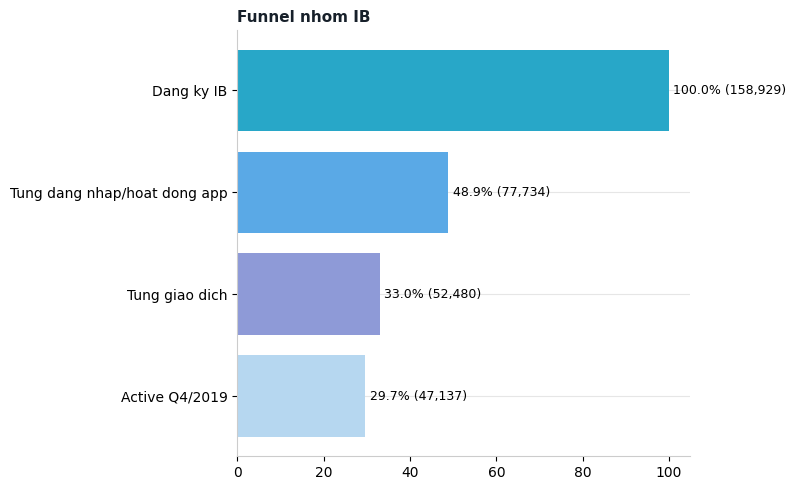

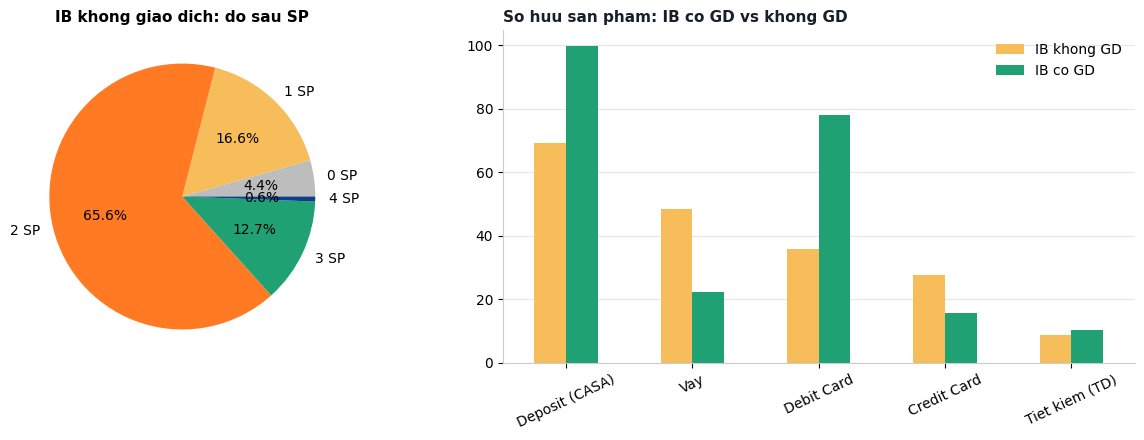

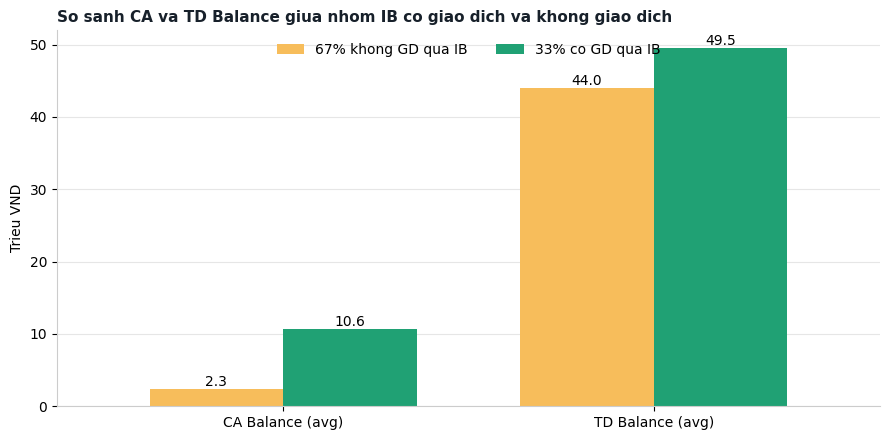

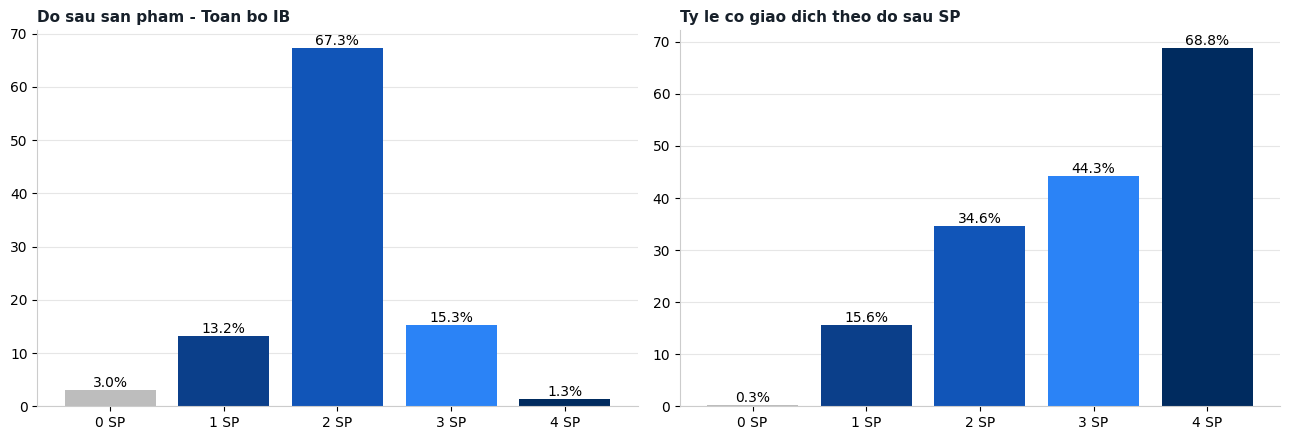

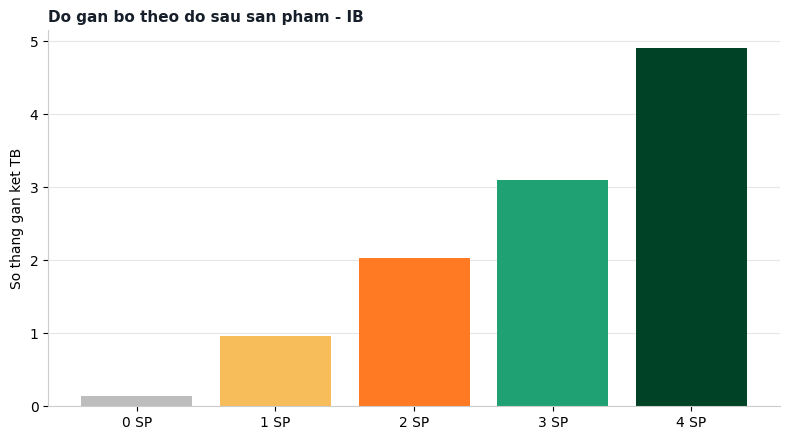

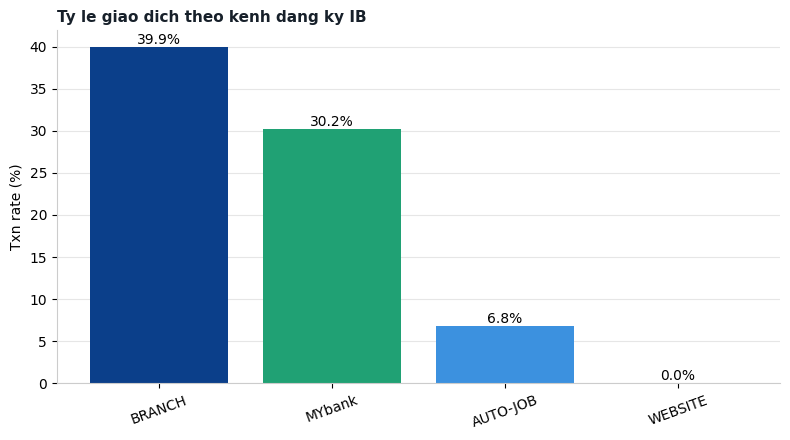

In [7]:
# 05 IB funnel
ib_ids = set(ib['CUSTOMER_NUMBER'])
q4_months = pd.to_datetime(['2019-10-31', '2019-11-30', '2019-12-31'])
funnel = pd.Series({
    'Dang ky IB': len(ib),
    'Tung dang nhap/hoat dong app': activity_clean.loc[activity_clean['CUSTOMER_NUMBER'].isin(ib_ids), 'CUSTOMER_NUMBER'].nunique(),
    'Tung giao dich': transaction_clean.loc[transaction_clean['CUSTOMER_NUMBER'].isin(ib_ids), 'CUSTOMER_NUMBER'].nunique(),
    'Active Q4/2019': transaction_clean.loc[transaction_clean['CUSTOMER_NUMBER'].isin(ib_ids) & transaction_clean['MONTH'].isin(q4_months), 'CUSTOMER_NUMBER'].nunique(),
})
rates = funnel / max(len(ib), 1) * 100
plt.figure(figsize=(8, 5))
plt.barh(funnel.index[::-1], rates.values[::-1], color=['#b6d7f0', '#8e9ad7', '#5aa9e6', '#28a7c8'])
for y, v, c in zip(range(len(funnel)), rates.values[::-1], funnel.values[::-1]):
    plt.text(v + 1, y, f'{v:.1f}% ({c:,.0f})', va='center', fontsize=9)
plt.xlim(0, 105); style_axes(plt.gca(), 'Funnel nhom IB')
plt.tight_layout(); plt.show()

# 06 inactive IB product analysis
ib_no_txn = ib[~ib['has_txn']]
no_txn_depth = ib_no_txn['product_depth'].value_counts(normalize=True).sort_index() * 100
compare_product_cols = ['COUNT_CA_ACCT', 'COUNT_OF_LOAN', 'COUNT_DEBITCARD', 'COUNT_CREDITCARD', 'COUNT_TD_ACCT']
compare_products = pd.DataFrame({
    'IB khong GD': ib_no_txn[compare_product_cols].gt(0).mean() * 100,
    'IB co GD': ib[ib['has_txn']][compare_product_cols].gt(0).mean() * 100,
}).rename(index={
    'COUNT_CA_ACCT': 'Deposit (CASA)',
    'COUNT_OF_LOAN': 'Vay',
    'COUNT_DEBITCARD': 'Debit Card',
    'COUNT_CREDITCARD': 'Credit Card',
    'COUNT_TD_ACCT': 'Tiet kiem (TD)',
})
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].pie(no_txn_depth.values, labels=[f'{int(i)} SP' for i in no_txn_depth.index], autopct='%1.1f%%', colors=['#bdbdbd', YELLOW, ORANGE, GREEN, BLUE])
axes[0].set_title('IB khong giao dich: do sau SP', fontsize=11, fontweight='bold')
compare_products.plot(kind='bar', ax=axes[1], color=[YELLOW, GREEN])
axes[1].tick_params(axis='x', rotation=25); axes[1].legend(frameon=False)
style_axes(axes[1], 'So huu san pham: IB co GD vs khong GD')
plt.tight_layout(); plt.show()

balance_compare = ib.assign(
    AVG_CA_BALANCE=ib['AVG_CA_BALANCE'].fillna(0),
    AVG_TD_BALANCE=ib['AVG_TD_BALANCE'].fillna(0),
).groupby('has_txn')[['AVG_CA_BALANCE', 'AVG_TD_BALANCE']].mean().div(1_000_000)
balance_compare = balance_compare.reindex([False, True]).rename(index={False: 'Khong GD qua IB', True: 'Co GD qua IB'}, columns={'AVG_CA_BALANCE': 'CA Balance (avg)', 'AVG_TD_BALANCE': 'TD Balance (avg)'})
txn_share = ib['has_txn'].value_counts(normalize=True).reindex([False, True]).fillna(0) * 100
ax = balance_compare.T.plot(kind='bar', figsize=(9, 4.5), color=[YELLOW, GREEN], width=0.72)
ax.legend([f'{txn_share.loc[False]:.0f}% khong GD qua IB', f'{txn_share.loc[True]:.0f}% co GD qua IB'], frameon=False, ncol=2, loc='upper center')
ax.tick_params(axis='x', rotation=0)
ax.bar_label(ax.containers[0], fmt='%.1f')
ax.bar_label(ax.containers[1], fmt='%.1f')
plt.ylabel('Trieu VND')
style_axes(ax, 'So sanh CA va TD Balance giua nhom IB co giao dich va khong giao dich')
plt.tight_layout(); plt.show()

# 07-09 IB depth, loyalty, onboarding
depth_ib = ib['product_depth'].value_counts(normalize=True).sort_index() * 100
tx_rate_by_depth = ib.groupby('product_depth')['has_txn'].mean().reindex(depth_ib.index) * 100
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar([f'{int(i)} SP' for i in depth_ib.index], depth_ib.values, color=['#bdbdbd', BLUE, '#1155b8', '#2b83f6', '#002b5f'])
axes[0].bar_label(axes[0].containers[0], fmt='%.1f%%'); style_axes(axes[0], 'Do sau san pham - Toan bo IB')
axes[1].bar([f'{int(i)} SP' for i in tx_rate_by_depth.index], tx_rate_by_depth.values, color=['#bdbdbd', BLUE, '#1155b8', '#2b83f6', '#002b5f'])
axes[1].bar_label(axes[1].containers[0], fmt='%.1f%%'); style_axes(axes[1], 'Ty le co giao dich theo do sau SP')
plt.tight_layout(); plt.show()

loyalty = ib.groupby('product_depth')['digital_engaged_months'].mean().reindex(depth_ib.index)
plt.figure(figsize=(8, 4.5))
plt.bar([f'{int(i)} SP' for i in loyalty.index], loyalty.values, color=['#bdbdbd', YELLOW, ORANGE, GREEN, '#004225'])
plt.ylabel('So thang gan ket TB'); style_axes(plt.gca(), 'Do gan bo theo do sau san pham - IB')
plt.tight_layout(); plt.show()

channel_rate = ib.groupby('EB_REGISTER_CHANNEL')['has_txn'].mean().sort_values(ascending=False) * 100
plt.figure(figsize=(8, 4.5))
plt.bar(channel_rate.index.astype(str), channel_rate.values, color=[BLUE, GREEN, '#3c91df', '#bbbbbb'][:len(channel_rate)])
plt.ylabel('Txn rate (%)'); plt.xticks(rotation=20); plt.bar_label(plt.gca().containers[0], fmt='%.1f%%')
style_axes(plt.gca(), 'Ty le giao dich theo kenh dang ky IB')
plt.tight_layout(); plt.show()



## Non-IB

C?c bi?u ?? t?p trung v?o kh?ch h?ng ch?a ??ng k? Internet Banking.

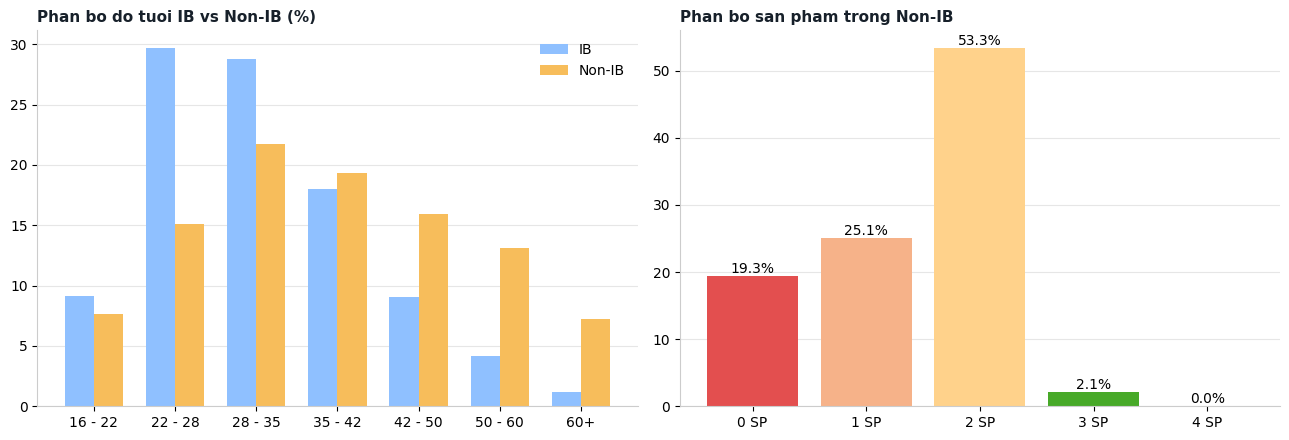

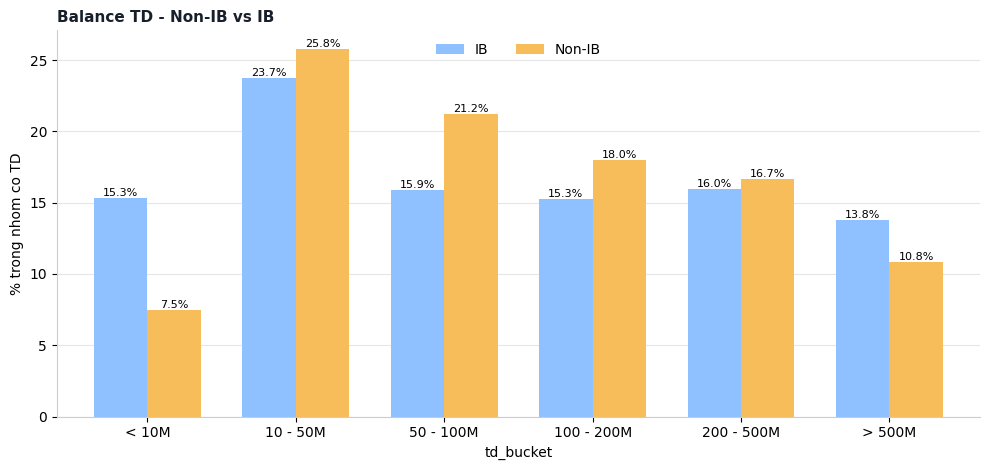

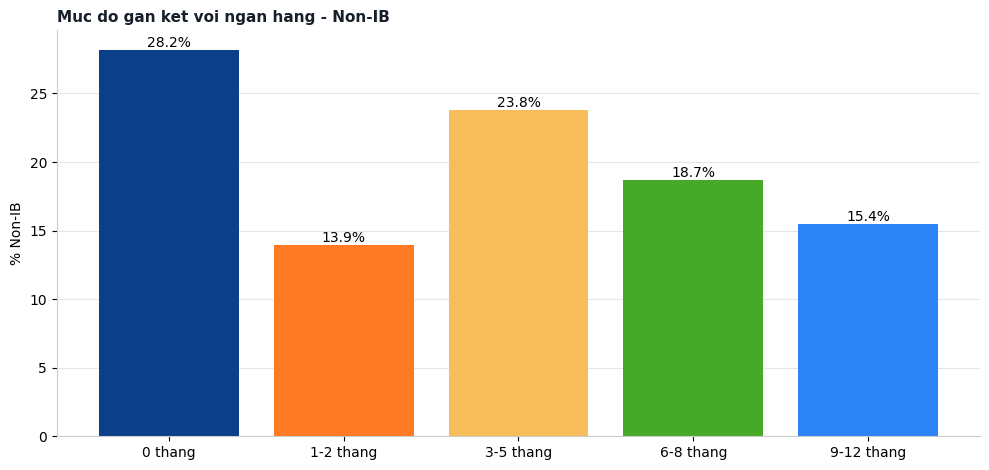

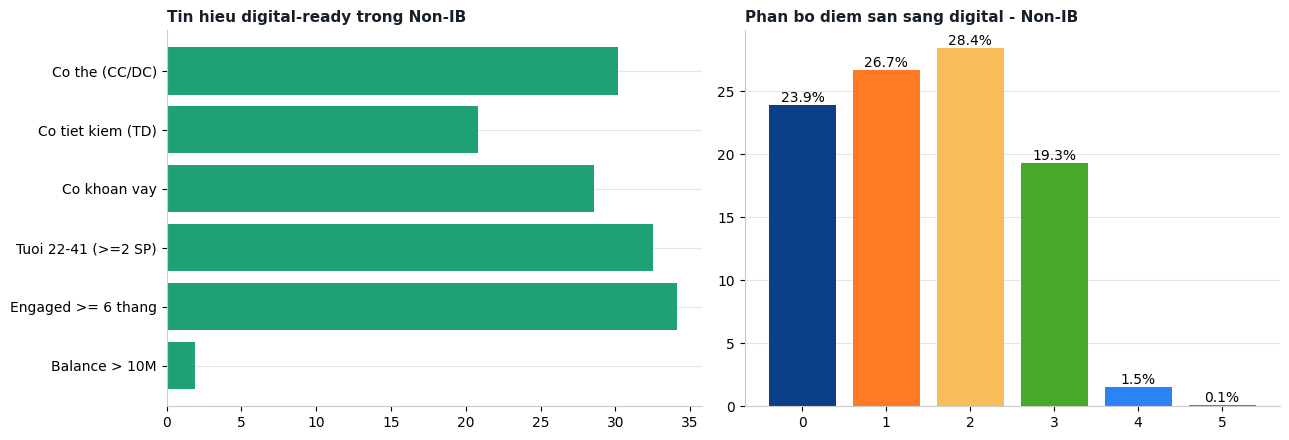

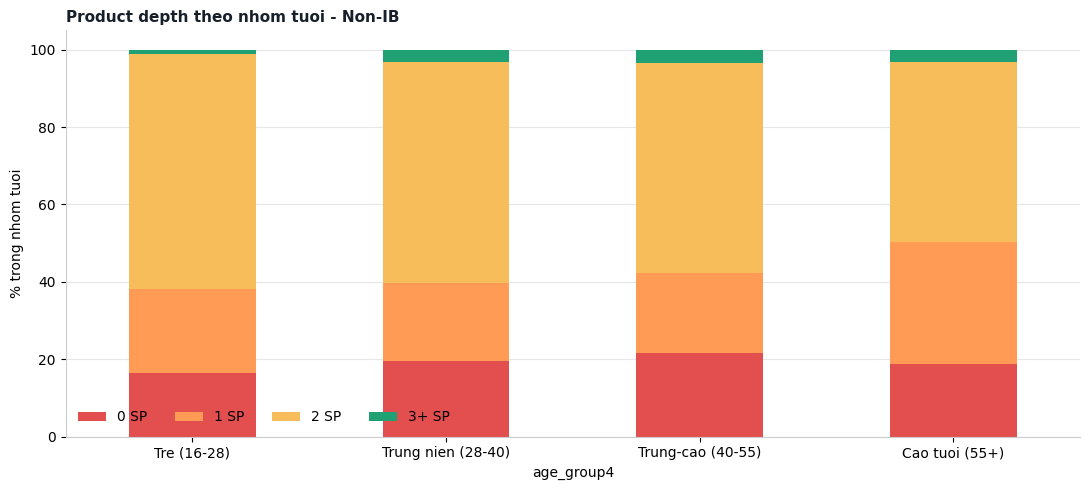

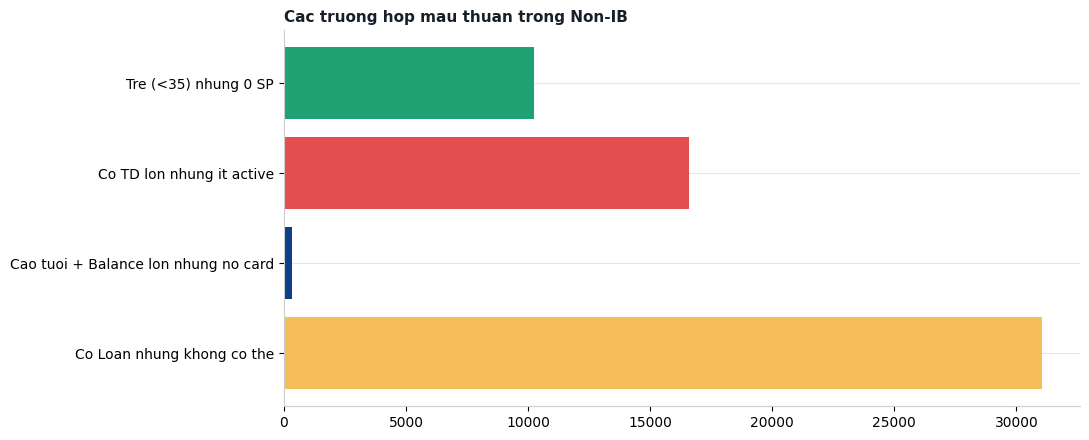

In [8]:
# 10-14 Non-IB views
age_bins_compare = [16, 22, 28, 35, 42, 50, 60, np.inf]
age_labels_compare = ['16 - 22', '22 - 28', '28 - 35', '35 - 42', '42 - 50', '50 - 60', '60+']
age_at_2019 = ((pd.Timestamp('2019-12-31') - customer_eda_base['DATE_OF_BIRTH']).dt.days / 365.25)
age_compare_base = customer_eda_base.assign(
    age_bucket_compare=pd.cut(age_at_2019, bins=age_bins_compare, labels=age_labels_compare, right=False)
)
non_age = age_compare_base.pivot_table(index='age_bucket_compare', columns='is_ib', values='CUSTOMER_NUMBER', aggfunc='count', observed=False).pipe(lambda t: t.div(t.sum(axis=0), axis=1) * 100).fillna(0).rename(columns={False: 'Non-IB', True: 'IB'})
non_depth = non['product_depth'].value_counts(normalize=True).sort_index() * 100
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(len(non_age))
axes[0].bar(x - 0.18, non_age.get('IB', 0), width=0.36, label='IB', color=LIGHT_BLUE)
axes[0].bar(x + 0.18, non_age.get('Non-IB', 0), width=0.36, label='Non-IB', color=YELLOW)
axes[0].set_xticks(x, non_age.index.astype(str)); axes[0].legend(frameon=False)
style_axes(axes[0], 'Phan bo do tuoi IB vs Non-IB (%)')
axes[1].bar([f'{int(i)} SP' for i in non_depth.index], non_depth.values, color=[RED, '#f6b289', '#ffd28b', '#47a928', BLUE])
axes[1].bar_label(axes[1].containers[0], fmt='%.1f%%'); style_axes(axes[1], 'Phan bo san pham trong Non-IB')
plt.tight_layout(); plt.show()

td_positive = deposit_clean.groupby('CUSTOMER_NUMBER', as_index=False)['AVG_TD_BALANCE'].mean()
td_positive = td_positive.loc[td_positive['AVG_TD_BALANCE'].fillna(0).gt(0)].merge(
    customer_clean[['CUSTOMER_NUMBER', 'IB_REGISTER_DATE']], on='CUSTOMER_NUMBER', how='left'
)
td_positive['segment'] = np.where(td_positive['IB_REGISTER_DATE'].notna(), 'IB', 'Non-IB')
td_bins = [-0.1, 10_000_000, 50_000_000, 100_000_000, 200_000_000, 500_000_000, np.inf]
td_labels = ['< 10M', '10 - 50M', '50 - 100M', '100 - 200M', '200 - 500M', '> 500M']
td_positive['td_bucket'] = pd.cut(td_positive['AVG_TD_BALANCE'], bins=td_bins, labels=td_labels)
td_dist = pd.crosstab(td_positive['td_bucket'], td_positive['segment'], normalize='columns').mul(100).reindex(td_labels).fillna(0)
ax = td_dist[['IB', 'Non-IB']].plot(kind='bar', figsize=(10, 4.8), color=[LIGHT_BLUE, YELLOW], width=0.72)
ax.tick_params(axis='x', rotation=0); ax.legend(frameon=False, ncol=2, loc='upper center')
ax.bar_label(ax.containers[0], fmt='%.1f%%', fontsize=8)
ax.bar_label(ax.containers[1], fmt='%.1f%%', fontsize=8)
plt.ylabel('% trong nhom co TD')
style_axes(ax, 'Balance TD - Non-IB vs IB')
plt.tight_layout(); plt.show()

bins = [-0.1, 0, 2, 5, 8, 12]
labels = ['0 thang', '1-2 thang', '3-5 thang', '6-8 thang', '9-12 thang']
non['engaged_bucket'] = pd.cut(non['engaged_months'], bins=bins, labels=labels)
engaged = non['engaged_bucket'].value_counts(normalize=True).reindex(labels) * 100
plt.figure(figsize=(10, 4.8))
plt.bar(engaged.index.astype(str), engaged.values, color=[BLUE, ORANGE, YELLOW, '#47a928', '#2b83f6'])
plt.bar_label(plt.gca().containers[0], fmt='%.1f%%'); plt.ylabel('% Non-IB')
style_axes(plt.gca(), 'Muc do gan ket voi ngan hang - Non-IB')
plt.tight_layout(); plt.show()

nonib_master_path = Path('Cluster_nonIB') / 'output' / 'nonib_master.parquet'
ready_base = pd.read_parquet(nonib_master_path) if nonib_master_path.exists() else non.copy()
if 'CREDITCARD_MAX' in ready_base.columns:
    ready_flags = pd.DataFrame({
        'CUSTOMER_NUMBER': ready_base['CUSTOMER_NUMBER'],
        'ready_has_card': ready_base[['CREDITCARD_MAX', 'DEBITCARD_MAX']].gt(0).any(axis=1),
        'ready_has_td': ready_base['TD_ACCT_MAX'].gt(0),
        'ready_has_loan': ready_base['LOAN_COUNT_MAX'].gt(0),
        'ready_young_2sp': ready_base['AGE'].between(22, 41, inclusive='both') & ready_base['PRODUCT_COUNT'].ge(2),
        'ready_engaged_6m': ready_base['MONTHS_WITH_DEPOSIT'].ge(6),
        'ready_balance_10m': ready_base['CA_BALANCE_LAST'].gt(10_000_000),
    })
else:
    ready_flags = pd.DataFrame({
        'CUSTOMER_NUMBER': ready_base['CUSTOMER_NUMBER'],
        'ready_has_card': ready_base[['COUNT_CREDITCARD', 'COUNT_DEBITCARD']].gt(0).any(axis=1),
        'ready_has_td': ready_base['COUNT_TD_ACCT'].gt(0),
        'ready_has_loan': ready_base['COUNT_OF_LOAN'].gt(0),
        'ready_young_2sp': ready_base['AGE'].between(22, 41, inclusive='both') & ready_base['product_depth'].ge(2),
        'ready_engaged_6m': ready_base['bank_engagement_months'].ge(6),
        'ready_balance_10m': ready_base['AVG_CA_BALANCE'].fillna(0).gt(10_000_000),
    })
ready_cols = ['ready_has_card', 'ready_has_td', 'ready_has_loan', 'ready_young_2sp', 'ready_engaged_6m', 'ready_balance_10m']
non = non.drop(columns=[c for c in ready_cols if c in non.columns], errors='ignore').merge(ready_flags, on='CUSTOMER_NUMBER', how='left')
ready_rate = non[ready_cols].mean() * 100
ready_rate.index = ['Co the (CC/DC)', 'Co tiet kiem (TD)', 'Co khoan vay', 'Tuoi 22-41 (>=2 SP)', 'Engaged >= 6 thang', 'Balance > 10M']
non['ready_score'] = non[ready_cols].sum(axis=1).clip(upper=5)
score_dist = non['ready_score'].value_counts(normalize=True).sort_index() * 100
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].barh(ready_rate.index[::-1], ready_rate.values[::-1], color=GREEN); style_axes(axes[0], 'Tin hieu digital-ready trong Non-IB')
axes[1].bar(score_dist.index.astype(str), score_dist.values, color=[BLUE, ORANGE, YELLOW, '#47a928', '#2b83f6', '#8e55d8'][:len(score_dist)])
axes[1].bar_label(axes[1].containers[0], fmt='%.1f%%'); style_axes(axes[1], 'Phan bo diem san sang digital - Non-IB')
plt.tight_layout(); plt.show()

age_depth_base = ready_base if 'PRODUCT_COUNT' in ready_base.columns else non.rename(columns={'product_depth': 'PRODUCT_COUNT'})
age_group_labels = ['Tre (16-28)', 'Trung nien (28-40)', 'Trung-cao (40-55)', 'Cao tuoi (55+)']
age_depth_base = age_depth_base.assign(
    age_group4=pd.cut(age_depth_base['AGE'], bins=[16, 28, 40, 55, np.inf], labels=age_group_labels, right=False),
    depth_group=np.minimum(age_depth_base['PRODUCT_COUNT'], 3).replace({3: '3+ SP', 0: '0 SP', 1: '1 SP', 2: '2 SP'}),
)
stacked = pd.crosstab(age_depth_base['age_group4'], age_depth_base['depth_group'], normalize='index') * 100
stacked = stacked.reindex(index=age_group_labels, columns=['0 SP', '1 SP', '2 SP', '3+ SP'], fill_value=0)
ax = stacked.plot(kind='bar', stacked=True, figsize=(11, 5), color=[RED, '#ff9b55', YELLOW, GREEN])
ax.legend(frameon=False, ncol=4); ax.tick_params(axis='x', rotation=0)
plt.ylabel('% trong nhom tuoi')
style_axes(ax, 'Product depth theo nhom tuoi - Non-IB')
plt.tight_layout(); plt.show()

case_base = ready_base if 'PRODUCT_COUNT' in ready_base.columns else non
if 'PRODUCT_COUNT' in case_base.columns:
    case_has_card = case_base[['CREDITCARD_MAX', 'DEBITCARD_MAX']].gt(0).any(axis=1)
    cases = pd.Series({
        'Tre (<35) nhung 0 SP': ((case_base['AGE'] < 35) & (case_base['PRODUCT_COUNT'] == 0)).sum(),
        'Co TD lon nhung it active': (case_base['HAS_TD'].astype(bool) & case_base['MONTHS_WITH_DEPOSIT'].le(5)).sum(),
        'Cao tuoi + Balance lon nhung no card': (case_base['AGE'].ge(55) & case_base['CA_BALANCE_MAX'].gt(30_000_000) & ~case_has_card).sum(),
        'Co Loan nhung khong co the': (case_base['HAS_LOAN'].astype(bool) & ~case_has_card).sum(),
    })
else:
    cases = pd.Series({
        'Tre (<35) nhung 0 SP': ((non['AGE'] < 35) & (non['product_depth'] == 0)).sum(),
        'Co TD lon nhung it active': (non['COUNT_TD_ACCT'].gt(0) & non['bank_engagement_months'].le(5)).sum(),
        'Cao tuoi + Balance lon nhung no card': (non['AGE'].ge(55) & non['AVG_CA_BALANCE'].gt(30_000_000) & ~non['ready_has_card']).sum(),
        'Co Loan nhung khong co the': (non['ready_has_loan'] & ~non['ready_has_card']).sum(),
    })
plt.figure(figsize=(11, 4.5))
plt.barh(cases.index[::-1], cases.values[::-1], color=[YELLOW, BLUE, RED, GREEN])
style_axes(plt.gca(), 'Cac truong hop mau thuan trong Non-IB')
plt.tight_layout(); plt.show()
